# Notebook 01: Data Cleaning & Preprocessing
## Weather Trend Forecasting — PM Accelerator Assessment
### Goal: Clean, validate, and prepare the Global Weather Repository dataset for analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Paths
RAW_DATA = Path('../data/raw/GlobalWeatherRepository.csv')
PROCESSED_DATA = Path('../data/processed/weather_cleaned.csv')
FIGURES_DIR = Path('../outputs/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Libraries loaded")

Libraries loaded


In [2]:
df = pd.read_csv(RAW_DATA)
print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.head(3)

Dataset shape: (144822, 41)
Rows: 144,822 | Columns: 41


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55


## 1. Initial Data Overview

In [3]:
# Data types and basic info
print("DATASET INFO")
df.info()

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144822 entries, 0 to 144821
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       144822 non-null  object 
 1   location_name                 144822 non-null  object 
 2   latitude                      144822 non-null  float64
 3   longitude                     144822 non-null  float64
 4   timezone                      144822 non-null  object 
 5   last_updated_epoch            144822 non-null  int64  
 6   last_updated                  144822 non-null  object 
 7   temperature_celsius           144822 non-null  float64
 8   temperature_fahrenheit        144822 non-null  float64
 9   condition_text                144822 non-null  object 
 10  wind_mph                      144822 non-null  float64
 11  wind_kph                      144822 non-null  float64
 12  wind_degree                   1

In [4]:
# Statistical summary
print("STATISTICAL SUMMARY")
df.describe().round(2)

STATISTICAL SUMMARY


,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,...,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,144822.00,144822.00,1.448220e+05,144822.00,144822.00,144822.00,144822.00,144822.00,144822.00,144822.00,...,144822.00,144822.00,144822.00,144822.00,144822.00,144822.00,144822.00,144822.00,144822.00,144822.00
mean,19.22,21.92,1.748080e+09,21.26,70.27,7.97,12.84,169.06,1014.05,29.94,...,18.16,447.16,57.50,14.76,10.07,23.78,47.68,1.68,2.57,49.97
std,24.41,65.78,1.860501e+07,9.60,17.28,7.09,11.41,103.66,10.14,0.30,...,13.64,739.84,30.42,23.23,34.59,36.15,147.12,0.93,2.42,35.10
min,-41.30,-175.20,1.715849e+09,-29.80,-21.60,2.20,3.60,1.00,947.00,27.96,...,3.60,-9999.00,0.00,0.00,-9999.00,0.17,-1848.15,1.00,1.00,0.00
25%,4.05,-6.84,1.732006e+09,15.70,60.30,3.80,6.10,80.00,1010.00,29.83,...,10.20,193.85,38.00,1.80,1.11,7.03,9.80,1.00,1.00,15.00
50%,17.25,23.24,1.748076e+09,23.70,74.60,6.70,10.80,161.00,1013.00,29.93,...,15.30,284.92,54.40,5.74,2.40,13.88,19.55,1.00,2.00,50.00
75%,40.40,49.88,1.764140e+09,27.90,82.30,11.00,17.60,256.00,1018.00,30.06,...,24.10,448.03,73.00,17.02,8.00,27.25,40.75,2.00,3.00,85.00
max,64.15,179.22,1.780294e+09,79.30,174.70,1841.20,2963.20,360.00,3006.00,88.77,...,2970.40,38879.40,480.70,427.70,521.33,1614.10,6037.29,6.00,10.00,100.00


## 2. Missing Values Analysis

In [5]:
# Missing values analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

missing_df = missing_df[missing_df['Missing Count'] > 0]
print(f"Columns with missing values: {len(missing_df)}")
print(missing_df)

Columns with missing values: 0
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


In [6]:
# Visualize missing values
if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    missing_df['Missing %'].plot(kind='bar', color='steelblue', ax=ax)
    ax.set_title('Missing Values by Column (%)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Missing %')
    ax.set_xlabel('Column')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '01_missing_values.png', dpi=150)
    plt.show()
    print("Saved: 01_missing_values.png")
else:
    print("No missing values found!")

No missing values found!


## 3. Duplicate Detection

In [7]:
# Check duplicates
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")

if dupes > 0:
    df = df.drop_duplicates()
    print(f"Dropped {dupes} duplicates. New shape: {df.shape}")
else:
    print("No duplicates found")

Duplicate rows: 0
No duplicates found


## 4. DateTime Parsing

In [8]:
# Parse last_updated as datetime
df['last_updated'] = pd.to_datetime(df['last_updated'])

# Extract time features
df['year']    = df['last_updated'].dt.year
df['month']   = df['last_updated'].dt.month
df['day']     = df['last_updated'].dt.day
df['hour']    = df['last_updated'].dt.hour
df['season']  = df['month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
})

print("DateTime parsed and time features extracted")
print(df[['last_updated', 'year', 'month', 'day', 'hour', 'season']].head())

DateTime parsed and time features extracted
         last_updated  year  month  day  hour  season
0 2024-05-16 13:15:00  2024      5   16    13  Spring
1 2024-05-16 10:45:00  2024      5   16    10  Spring
2 2024-05-16 09:45:00  2024      5   16     9  Spring
3 2024-05-16 10:45:00  2024      5   16    10  Spring
4 2024-05-16 09:45:00  2024      5   16     9  Spring


## 5. Drop Redundant Columns

In [9]:
# Drop redundant duplicate-unit columns (keep metric, drop imperial)
cols_to_drop = [
    'temperature_fahrenheit',  # keep celsius
    'wind_mph',                # keep kph
    'pressure_in',             # keep mb
    'precip_in',               # keep mm
    'feels_like_fahrenheit',   # keep celsius
    'visibility_miles',        # keep km
    'gust_mph',                # keep kph
    'last_updated_epoch',      # already parsed last_updated
]

df = df.drop(columns=cols_to_drop)
print(f"Dropped {len(cols_to_drop)} redundant columns")
print(f"New shape: {df.shape}")
print(f"Remaining columns: {df.columns.tolist()}")

Dropped 8 redundant columns
New shape: (144822, 38)
Remaining columns: ['country', 'location_name', 'latitude', 'longitude', 'timezone', 'last_updated', 'temperature_celsius', 'condition_text', 'wind_kph', 'wind_degree', 'wind_direction', 'pressure_mb', 'precip_mm', 'humidity', 'cloud', 'feels_like_celsius', 'visibility_km', 'uv_index', 'gust_kph', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise', 'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination', 'year', 'month', 'day', 'hour', 'season']


## 6. Outlier Detection & Treatment

In [10]:
# Define numeric columns to check for outliers
numeric_cols = [
    'temperature_celsius', 'humidity', 'pressure_mb',
    'wind_kph', 'precip_mm', 'visibility_km', 'uv_index',
    'air_quality_PM2.5', 'air_quality_PM10'
]

# IQR method
outlier_summary = []
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({
        'Column': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2),
        'Outlier Count': n_outliers,
        'Outlier %': round(n_outliers / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))

             Column      Q1      Q3   IQR  Lower Bound  Upper Bound  Outlier Count  Outlier %
temperature_celsius   15.70   27.90 12.20        -2.60        46.20           2381       1.64
           humidity   51.00   86.00 35.00        -1.50       138.50              0       0.00
        pressure_mb 1010.00 1018.00  8.00       998.00      1030.00           4183       2.89
           wind_kph    6.10   17.60 11.50       -11.15        34.85           2448       1.69
          precip_mm    0.00    0.02  0.02        -0.03         0.05          29275      20.21
      visibility_km   10.00   10.00  0.00        10.00        10.00          30690      21.19
           uv_index    0.10    6.00  5.90        -8.75        14.85            222       0.15
  air_quality_PM2.5    7.03   27.25 20.22       -23.30        57.58          12023       8.30
   air_quality_PM10    9.80   40.75 30.94       -36.61        87.17          15464      10.68


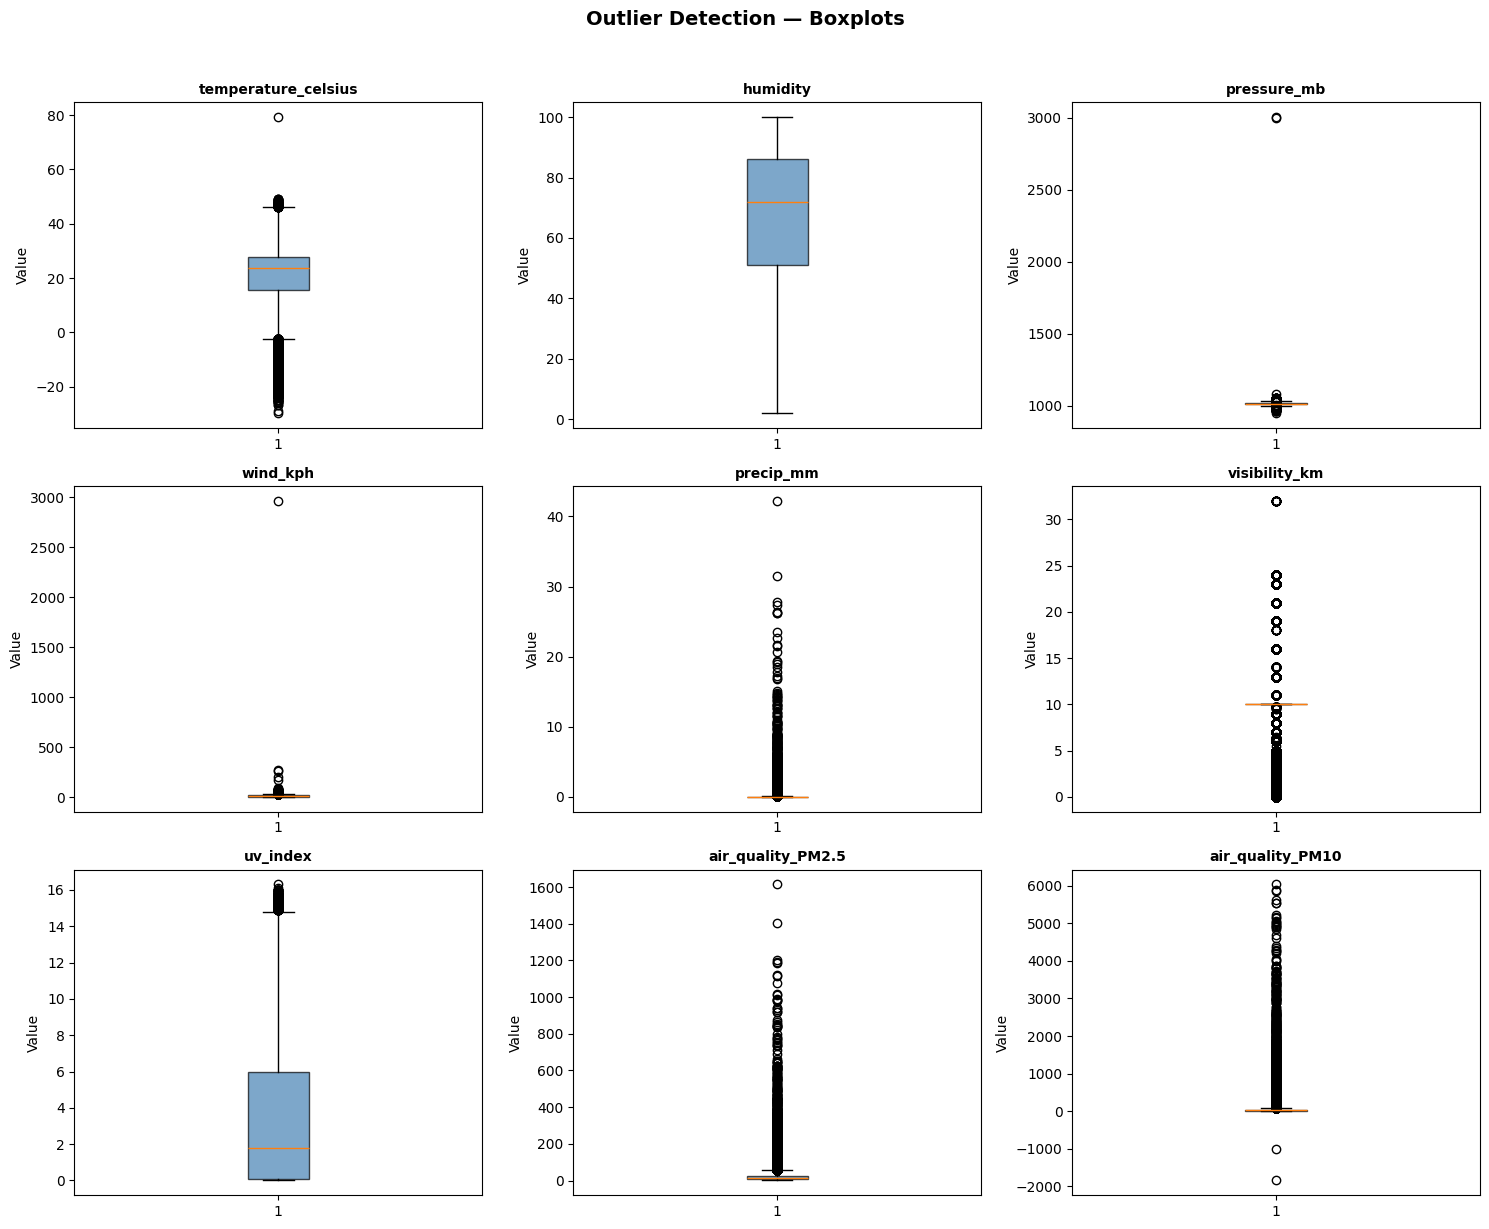

Saved: 02_outliers_boxplot.png


In [11]:
# Visualize outliers with boxplots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Value')

plt.suptitle('Outlier Detection — Boxplots', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_outliers_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 02_outliers_boxplot.png")

In [12]:
# Cap outliers using IQR (winsorizing) instead of dropping rows
# We cap rather than drop to preserve 144k rows
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower, upper=upper)

print("Outliers capped using IQR winsorizing")
print(f"Dataset shape preserved: {df.shape}")

Outliers capped using IQR winsorizing
Dataset shape preserved: (144822, 38)


## 7. Add Continent Column 

In [13]:
# Map countries to continents
continent_map = {
    'Afghanistan':'Asia','Albania':'Europe','Algeria':'Africa',
    'Angola':'Africa','Argentina':'South America','Armenia':'Asia',
    'Australia':'Oceania','Austria':'Europe','Azerbaijan':'Asia',
    'Bahrain':'Asia','Bangladesh':'Asia','Belarus':'Europe',
    'Belgium':'Europe','Bolivia':'South America','Bosnia And Herzegovina':'Europe',
    'Brazil':'South America','Bulgaria':'Europe','Cambodia':'Asia',
    'Cameroon':'Africa','Canada':'North America','Chile':'South America',
    'China':'Asia','Colombia':'South America','Croatia':'Europe',
    'Cuba':'North America','Cyprus':'Europe','Czech Republic':'Europe',
    'Denmark':'Europe','Dominican Republic':'North America','Ecuador':'South America',
    'Egypt':'Africa','Estonia':'Europe','Ethiopia':'Africa',
    'Finland':'Europe','France':'Europe','Georgia':'Asia',
    'Germany':'Europe','Ghana':'Africa','Greece':'Europe',
    'Guatemala':'North America','Honduras':'North America','Hungary':'Europe',
    'India':'Asia','Indonesia':'Asia','Iran':'Asia',
    'Iraq':'Asia','Ireland':'Europe','Israel':'Asia',
    'Italy':'Europe','Jamaica':'North America','Japan':'Asia',
    'Jordan':'Asia','Kazakhstan':'Asia','Kenya':'Africa',
    'Kuwait':'Asia','Latvia':'Europe','Lebanon':'Asia',
    'Libya':'Africa','Lithuania':'Europe','Luxembourg':'Europe',
    'Malaysia':'Asia','Mexico':'North America','Moldova':'Europe',
    'Morocco':'Africa','Mozambique':'Africa','Myanmar':'Asia',
    'Nepal':'Asia','Netherlands':'Europe','New Zealand':'Oceania',
    'Nicaragua':'North America','Nigeria':'Africa','North Korea':'Asia',
    'Norway':'Europe','Oman':'Asia','Pakistan':'Asia',
    'Panama':'North America','Paraguay':'South America','Peru':'South America',
    'Philippines':'Asia','Poland':'Europe','Portugal':'Europe',
    'Qatar':'Asia','Romania':'Europe','Russia':'Europe',
    'Saudi Arabia':'Asia','Senegal':'Africa','Serbia':'Europe',
    'Singapore':'Asia','Slovakia':'Europe','Slovenia':'Europe',
    'Somalia':'Africa','South Africa':'Africa','South Korea':'Asia',
    'Spain':'Europe','Sri Lanka':'Asia','Sudan':'Africa',
    'Sweden':'Europe','Switzerland':'Europe','Syria':'Asia',
    'Taiwan':'Asia','Tanzania':'Africa','Thailand':'Asia',
    'Tunisia':'Africa','Turkey':'Asia','Uganda':'Africa',
    'Ukraine':'Europe','United Arab Emirates':'Asia',
    'United Kingdom':'Europe','United States':'North America',
    'Uruguay':'South America','Uzbekistan':'Asia','Venezuela':'South America',
    'Vietnam':'Asia','Yemen':'Asia','Zambia':'Africa','Zimbabwe':'Africa'
}

df['continent'] = df['country'].map(continent_map)
df['continent'] = df['continent'].fillna('Other')

print("Continent column added")
print(df['continent'].value_counts())

Continent column added
continent
Other            56436
Asia             30888
Europe           27081
Africa           14865
South America     7407
North America     6658
Oceania           1487
Name: count, dtype: int64


## 8. Final Validation 

In [14]:
# Final check
print("FINAL DATASET SUMMARY")
print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")
print(f"Date range: {df['last_updated'].min()} → {df['last_updated'].max()}")
print(f"Countries: {df['country'].nunique()}")
print(f"Continents: {df['continent'].value_counts().to_dict()}")
print(f"\nColumns: {df.columns.tolist()}")

FINAL DATASET SUMMARY
Shape: (144822, 39)
Missing values: 0
Duplicates: 0
Date range: 2024-05-16 01:45:00 → 2026-06-01 19:15:00
Countries: 211
Continents: {'Other': 56436, 'Asia': 30888, 'Europe': 27081, 'Africa': 14865, 'South America': 7407, 'North America': 6658, 'Oceania': 1487}

Columns: ['country', 'location_name', 'latitude', 'longitude', 'timezone', 'last_updated', 'temperature_celsius', 'condition_text', 'wind_kph', 'wind_degree', 'wind_direction', 'pressure_mb', 'precip_mm', 'humidity', 'cloud', 'feels_like_celsius', 'visibility_km', 'uv_index', 'gust_kph', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise', 'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination', 'year', 'month', 'day', 'hour', 'season', 'continent']


In [15]:
# Extended continent mapping for unmapped countries (mostly small nations, alternative names, and non-English variants)
extra_continent_map = {
    # Small European nations
    'Andorra': 'Europe', 'Monaco': 'Europe', 'San Marino': 'Europe',
    'Liechtenstein': 'Europe', 'Malta': 'Europe', 'Iceland': 'Europe',
    'Kosovo': 'Europe', 'Macedonia': 'Europe', 'Montenegro': 'Europe',
    'Bosnia and Herzegovina': 'Europe',

    # French names
    'Bélgica': 'Europe', 'Estonie': 'Europe', 'Letonia': 'Europe',
    'Mexique': 'North America', 'Marrocos': 'Africa',

    # German names
    'Jemen': 'Asia', 'Komoren': 'Africa', 'Saudi Arabien': 'Asia',
    'Südkorea': 'Asia', 'Turkménistan': 'Asia',

    # Portuguese names
    'Inde': 'Asia', 'Malásia': 'Asia', 'Polônia': 'Europe',

    # Cyrillic
    'Гватемала': 'North America', 'Польша': 'Europe', 'Турция': 'Asia',

    # Arabic
    'كولومبيا': 'South America',

    # Chinese
    '火鸡': 'Asia',

    # USA variants
    'USA United States of America': 'North America',
    'United States of America': 'North America',

    # Africa
    'Benin': 'Africa', 'Bhutan': 'Asia', 'Botswana': 'Africa',
    'Burkina Faso': 'Africa', 'Burundi': 'Africa', 'Cape Verde': 'Africa',
    'Central African Republic': 'Africa', 'Chad': 'Africa',
    'Comoros': 'Africa', 'Congo': 'Africa', 'Cote d\'Ivoire': 'Africa',
    'Democratic Republic of Congo': 'Africa', 'Djibouti': 'Africa',
    'Equatorial Guinea': 'Africa', 'Eritrea': 'Africa', 'Gabon': 'Africa',
    'Gambia': 'Africa', 'Guinea': 'Africa', 'Guinea-Bissau': 'Africa',
    'Lesotho': 'Africa', 'Liberia': 'Africa', 'Madagascar': 'Africa',
    'Malawi': 'Africa', 'Mali': 'Africa', 'Mauritania': 'Africa',
    'Mauritius': 'Africa', 'Namibia': 'Africa', 'Niger': 'Africa',
    'Rwanda': 'Africa', 'Seychelles Islands': 'Africa',
    'Sierra Leone': 'Africa', 'Swaziland': 'Africa', 'Togo': 'Africa',

    # Asia
    'Brunei Darussalam': 'Asia', 'Kyrghyzstan': 'Asia',
    'Lao People\'s Democratic Republic': 'Asia', 'Maldives': 'Asia',
    'Mongolia': 'Asia', 'Tajikistan': 'Asia', 'Timor-Leste': 'Asia',
    'Turkmenistan': 'Asia',

    # North America / Caribbean
    'Antigua and Barbuda': 'North America', 'Bahamas': 'North America',
    'Barbados': 'North America', 'Belize': 'North America',
    'Costa Rica': 'North America', 'Dominica': 'North America',
    'El Salvador': 'North America', 'Grenada': 'North America',
    'Haiti': 'North America', 'Jamaica': 'North America',
    'Saint Kitts and Nevis': 'North America', 'Saint Lucia': 'North America',
    'Saint Vincent and the Grenadines': 'North America',
    'Saint-Vincent-et-les-Grenadines': 'North America',
    'Trinidad and Tobago': 'North America',

    # South America
    'Guyana': 'South America', 'Suriname': 'South America',

    # Oceania
    'Fiji Islands': 'Oceania', 'Kiribati': 'Oceania',
    'Marshall Islands': 'Oceania', 'Micronesia': 'Oceania',
    'Palau': 'Oceania', 'Papua New Guinea': 'Oceania',
    'Samoa': 'Oceania', 'Solomon Islands': 'Oceania',
    'Tonga': 'Oceania', 'Tuvalu': 'Oceania', 'Vanuatu': 'Oceania',

    # Other
    'Vatican City': 'Europe',
}

# Apply the extra mapping only to 'Other' rows
mask = df['continent'] == 'Other'
df.loc[mask, 'continent'] = df.loc[mask, 'country'].map(extra_continent_map)
df['continent'] = df['continent'].fillna('Other')

# Check result
print("Updated continent distribution:")
print(df['continent'].value_counts())
print(f"\nStill 'Other': {(df['continent'] == 'Other').sum()}")
print("Remaining unmapped:", df[df['continent'] == 'Other']['country'].unique())

Updated continent distribution:
continent
Africa           37904
Asia             36834
Europe           34514
North America    17021
Oceania           9660
South America     8889
Name: count, dtype: int64

Still 'Other': 0
Remaining unmapped: []


## 9. Data Normalization

In [16]:
from sklearn.preprocessing import StandardScaler

scale_cols = [
    'temperature_celsius', 'humidity', 'pressure_mb',
    'wind_kph', 'precip_mm', 'visibility_km', 'uv_index'
]

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[scale_cols] = scaler.fit_transform(df[scale_cols])

print("Normalized sample:")
print(df_scaled[scale_cols].describe().round(3))

Normalized sample:
       temperature_celsius    humidity  pressure_mb    wind_kph   precip_mm  \
count           144822.000  144822.000   144822.000  144822.000  144822.000   
mean                -0.000      -0.000        0.000       0.000       0.000   
std                  1.000       1.000        1.000       1.000       1.000   
min                 -2.569      -2.727       -2.454      -1.141      -0.631   
25%                 -0.606      -0.665       -0.619      -0.828      -0.631   
50%                  0.252       0.220       -0.160      -0.240      -0.631   
75%                  0.703       0.809        0.605       0.610       0.339   
max                  2.666       1.398        2.441       2.767       1.795   

       visibility_km    uv_index  
count       144822.0  144822.000  
mean             0.0      -0.000  
std              0.0       1.000  
min              0.0      -0.921  
25%              0.0      -0.893  
50%              0.0      -0.411  
75%              0.0    

## 10.Save

In [17]:
# Save cleaned dataset
df.to_csv(PROCESSED_DATA, index=False)
print(f"Cleaned dataset saved to: {PROCESSED_DATA}")
print(f"Final shape: {df.shape}")

Cleaned dataset saved to: ..\data\processed\weather_cleaned.csv
Final shape: (144822, 39)
